In [20]:
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

LEARNING_RATE = 1e-3
EPOCHS = 4
STEPS_IN_EPOCH = 8

In [21]:
def lr_step_values(scheduler):
    # Get learning rates as each training step
    learning_rates = []
    # EPOCHS*STEPS_IN_EPOCH：表示总的优化步（optimizer steps）
    for i in range(EPOCHS*STEPS_IN_EPOCH):
        optimizer.step()
        learning_rates.append(optimizer.param_groups[0]["lr"])
        scheduler.step()
    return learning_rates

In [22]:
def vis_lr_values(lr_values, title=''):
    # Visualize learinig rate scheduler
    fig, ax = plt.subplots(1,1, figsize=(10,5))
    ax.plot(range(EPOCHS*STEPS_IN_EPOCH), 
            lr_values,
            marker='o', 
            color='black')
    ax.set_xlim([0, EPOCHS*STEPS_IN_EPOCH])
    ax.set_ylim([0, LEARNING_RATE + 0.0001])
    ax.set_xlabel('Steps')
    ax.set_ylabel('Learning Rate')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MultipleLocator(STEPS_IN_EPOCH))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.show()

1 StepLR

In [23]:
from torch.optim.lr_scheduler import StepLR # Import your choice of scheduler here

# Set model and optimizer
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, 
                   step_size = 4, # Period of learning rate decay
                   gamma = 0.5) # Multiplicative factor of learning rate decay
learning_rates_step = lr_step_values(scheduler)

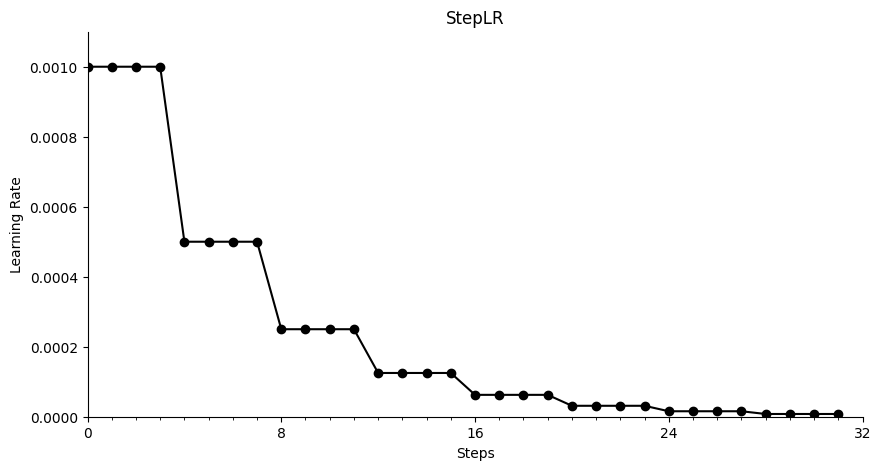

In [24]:
vis_lr_values(learning_rates_step, 'StepLR')